# DNN — Scikit-Learn Pipeline

## Model: Deep Neural Network (Multi-Layer Perceptron)
- **Dataset**: UCI HAR — 7,352 train / 2,947 test, 561 sensor features
- **Task**: Classify 6 human activities (3 dynamic, 3 static)
- **Framework showcase**: Activation function comparison (ReLU vs Tanh vs Logistic)

## Evaluation Strategy
- **Metrics**: Accuracy, Macro F1, per-class F1, confusion matrix
- **Training curves**: `loss_curve_` + `validation_scores_` (with early stopping)

## Pipeline
1. Load data + config
2. Simple baseline DNN
3. Training history visualization
4. Activation function comparison (showcase)
5. Architecture sweep
6. Best model — full evaluation
7. Performance benchmarks
8. Save results

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../..')

from sklearn.neural_network import MLPClassifier
from utils.data_loader import load_processed_data
from utils.visualization import (plot_confusion_matrix_multiclass,
                                  plot_per_class_f1, plot_training_history)
from utils.metrics import evaluate_classifier
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

import os
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Configuration
RANDOM_STATE = 113
FRAMEWORK = "Scikit-Learn"
N_CLASSES = 6
ACTIVITY_NAMES = [
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
    "SITTING", "STANDING", "LAYING"
]

# Step 1: Load preprocessed UCI HAR
X_train, X_test, y_train, y_test, meta = load_processed_data('dnn')

print("=" * 60)
print(f"[1/8] Data loaded — {FRAMEWORK} DNN")
print("=" * 60)
print(f"  Train: {X_train.shape} | Test: {X_test.shape}")
print(f"  Classes: {N_CLASSES} ({', '.join(ACTIVITY_NAMES)})")
print(f"  Label range: [{y_train.min()}, {y_train.max()}]")
print(f"  Dtype: {X_train.dtype}")

[1/8] Data loaded — Scikit-Learn DNN
  Train: (7352, 561) | Test: (2947, 561)
  Classes: 6 (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING)
  Label range: [0, 5]
  Dtype: float32


In [2]:
# Step 2: Simple baseline — single hidden layer, default settings

"""
MLPClassifier uses backprop with Adam optimizer by default
early_stopping=True holds out 10% of train for validation tracking
"""

print("=" * 60)
print("[2/8] SIMPLE BASELINE DNN")
print("=" * 60)

baseline = MLPClassifier(
    hidden_layer_sizes=(128,),  # single hidden layer, 128 neurons
    activation='relu',          # standard DNN activation
    solver='adam',              # adaptive learning rate optimizer
    max_iter=200,               # max epochs
    random_state=RANDOM_STATE,
    early_stopping=True,        # hold out 10% for validation
    validation_fraction=0.1,
    n_iter_no_change=15,        # patience before stopping
    verbose=False
)

with track_performance() as perf:
    baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)
base_metrics = evaluate_classifier(y_test, y_pred_base)

print(f"\n  Architecture: 561 → 128 → 6")
print(f"  Epochs run: {baseline.n_iter_}")
print(f"  Final train loss: {baseline.loss_curve_[-1]:.4f}")
print(f"  Best val score: {max(baseline.validation_scores_):.4f}")
print(f"  Training time: {perf['time']:.2f}s")
print(f"\n  Test Results:")
print(f"    Accuracy: {base_metrics['accuracy']:.4f}")
print(f"    Macro F1: {base_metrics['macro_f1']:.4f}")

[2/8] SIMPLE BASELINE DNN

  Architecture: 561 → 128 → 6
  Epochs run: 30
  Final train loss: 0.0196
  Best val score: 0.9796
  Training time: 1.30s

  Test Results:
    Accuracy: 0.9440
    Macro F1: 0.9442


[3/8] TRAINING HISTORY


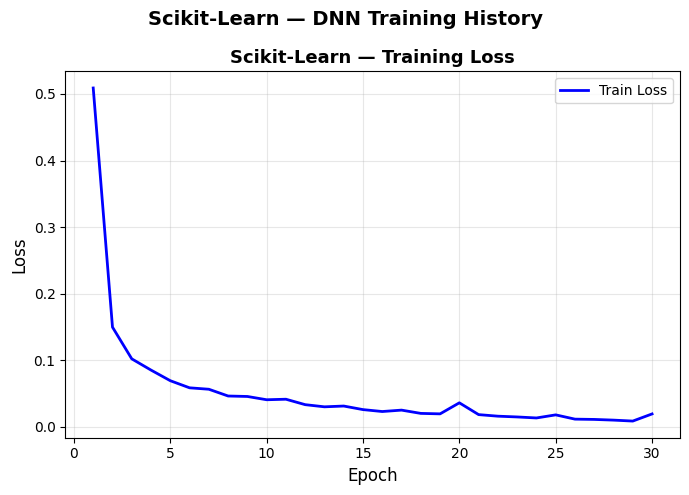

  Epochs: 30
  Loss: 0.5090 → 0.0196
  Val acc: 0.9280 → 0.9796


In [3]:
# Step 3: Visualize training curves from baseline

"""
MLPClassifier exposes loss_curve_ (train loss per epoch)
and validation_scores_ (accuracy on held-out 10%) when early_stopping=True
"""

print("=" * 60)
print("[3/8] TRAINING HISTORY")
print("=" * 60)

history = {
    'train_loss': baseline.loss_curve_,
    'val_acc': baseline.validation_scores_
}

plot_training_history(history, FRAMEWORK,
                      save_path=f'{RESULTS_DIR}/training_history_baseline.png')

print(f"  Epochs: {len(baseline.loss_curve_)}")
print(f"  Loss: {baseline.loss_curve_[0]:.4f} → {baseline.loss_curve_[-1]:.4f}")
print(f"  Val acc: {baseline.validation_scores_[0]:.4f} → {max(baseline.validation_scores_):.4f}")

[4/8] ACTIVATION FUNCTION COMPARISON (SHOWCASE)

  Training with activation='relu'...
    Epochs: 30 | Acc: 0.9440 | F1: 0.9442

  Training with activation='tanh'...
    Epochs: 51 | Acc: 0.9437 | F1: 0.9440

  Training with activation='logistic'...
    Epochs: 73 | Acc: 0.9477 | F1: 0.9481


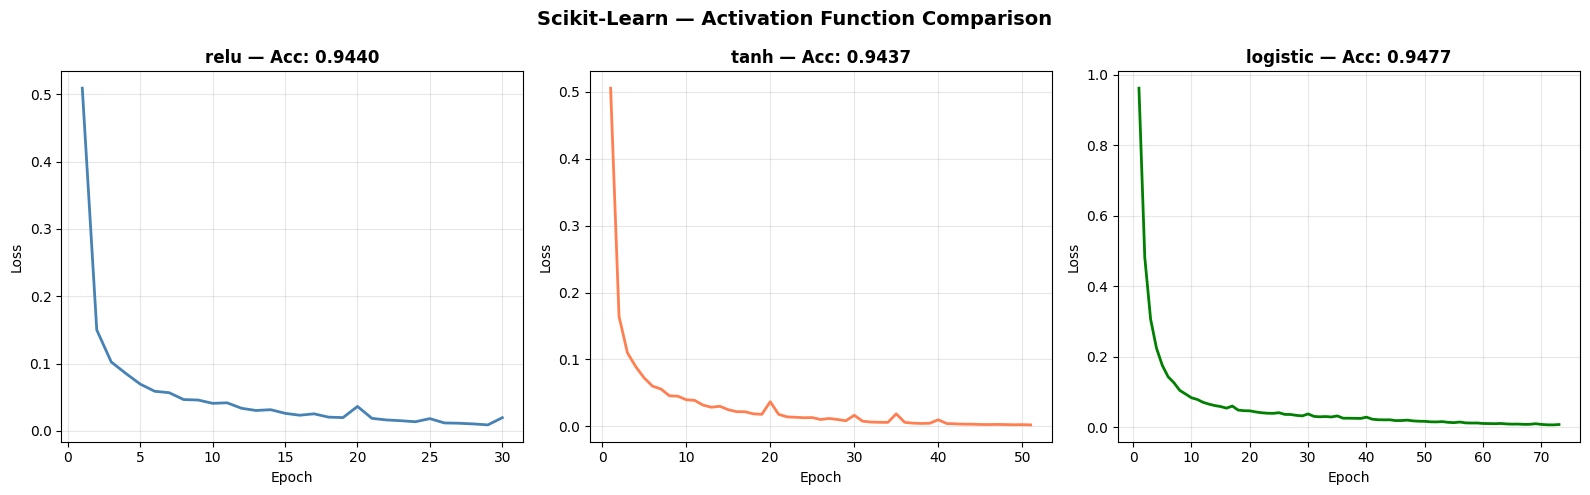


  Activation        Acc       F1   Epochs   Final Loss
  ------------------------------------------------
  relu           0.9440   0.9442       30       0.0196
  tanh           0.9437   0.9440       51       0.0022
  logistic       0.9477   0.9481       73       0.0075


In [4]:
# Step 4: SK showcase — activation function comparison

"""
MLPClassifier supports 3 activations: relu, tanh, logistic (sigmoid)
This is the key architectural choice for hidden layers —
relu is the modern default, but tanh/logistic have historical significance
"""

print("=" * 60)
print("[4/8] ACTIVATION FUNCTION COMPARISON (SHOWCASE)")
print("=" * 60)

activations = ['relu', 'tanh', 'logistic']
activation_results = {}

for act in activations:
    print(f"\n  Training with activation='{act}'...")
    mlp = MLPClassifier(
        hidden_layer_sizes=(128,),
        activation=act,
        solver='adam',
        max_iter=200,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        verbose=False
    )
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    metrics = evaluate_classifier(y_test, y_pred)

    activation_results[act] = {
        'accuracy': metrics['accuracy'],
        'macro_f1': metrics['macro_f1'],
        'epochs': mlp.n_iter_,
        'final_loss': mlp.loss_curve_[-1],
        'loss_curve': mlp.loss_curve_
    }
    print(f"    Epochs: {mlp.n_iter_} | Acc: {metrics['accuracy']:.4f} | F1: {metrics['macro_f1']:.4f}")

# Plot loss curves side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {'relu': 'steelblue', 'tanh': 'coral', 'logistic': 'green'}

for ax, act in zip(axes, activations):
    r = activation_results[act]
    ax.plot(range(1, r['epochs'] + 1), r['loss_curve'], color=colors[act], linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f"{act} — Acc: {r['accuracy']:.4f}", fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle(f'{FRAMEWORK} — Activation Function Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/activation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f"\n  {'Activation':<12} {'Acc':>8} {'F1':>8} {'Epochs':>8} {'Final Loss':>12}")
print(f"  {'-'*48}")
for act in activations:
    r = activation_results[act]
    print(f"  {act:<12} {r['accuracy']:>8.4f} {r['macro_f1']:>8.4f} {r['epochs']:>8} {r['final_loss']:>12.4f}")

[5/8] ARCHITECTURE SWEEP

  Training: 64 ...
    Acc: 0.9457 | F1: 0.9459 | Params: 36,358 | Epochs: 58

  Training: 128 ...
    Acc: 0.9440 | F1: 0.9442 | Params: 72,710 | Epochs: 30

  Training: 256 ...
    Acc: 0.9484 | F1: 0.9485 | Params: 145,414 | Epochs: 50

  Training: 128-64 ...
    Acc: 0.9491 | F1: 0.9493 | Params: 80,582 | Epochs: 42

  Training: 256-128 ...
    Acc: 0.9416 | F1: 0.9413 | Params: 177,542 | Epochs: 31

  Training: 256-128-64 ...
    Acc: 0.9477 | F1: 0.9471 | Params: 185,414 | Epochs: 38


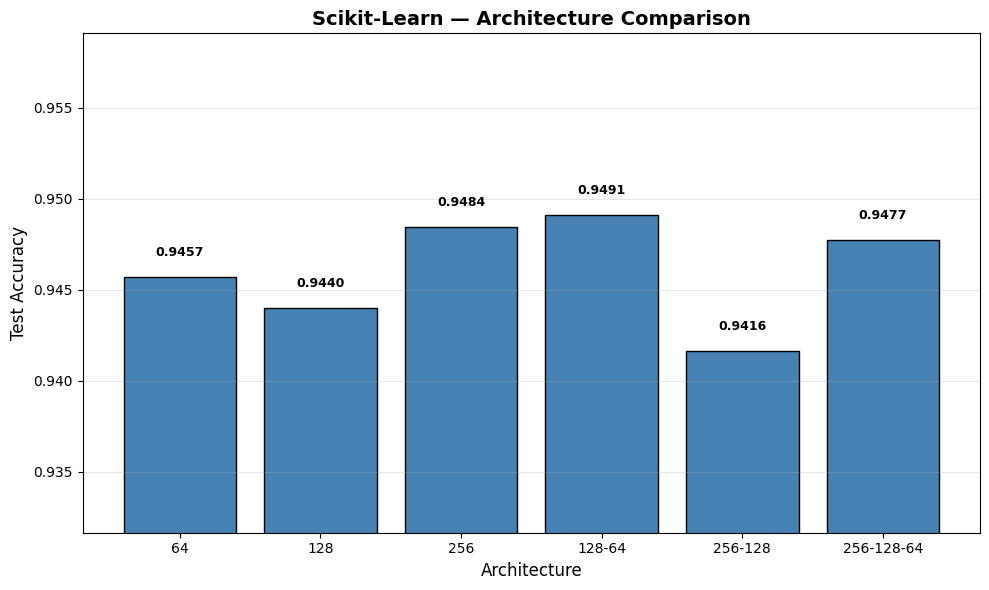


  Architecture          Acc       F1     Params   Epochs
  ----------------------------------------------------
  64                 0.9457   0.9459     36,358       58
  128                0.9440   0.9442     72,710       30
  256                0.9484   0.9485    145,414       50
  128-64             0.9491   0.9493     80,582       42
  256-128            0.9416   0.9413    177,542       31
  256-128-64         0.9477   0.9471    185,414       38

  Best: 128-64 (Acc: 0.9491)


In [5]:
# Step 5: Architecture sweep — how does depth/width affect performance?
# Test different hidden layer configurations from shallow+wide to deep+narrow

print("=" * 60)
print("[5/8] ARCHITECTURE SWEEP")
print("=" * 60)

architectures = {
    '64':           (64,),
    '128':          (128,),
    '256':          (256,),
    '128-64':       (128, 64),
    '256-128':      (256, 128),
    '256-128-64':   (256, 128, 64),
}

arch_results = {}

for name, layers in architectures.items():
    print(f"\n  Training: {name} ...")
    mlp = MLPClassifier(
        hidden_layer_sizes=layers,
        activation='relu',
        solver='adam',
        max_iter=200,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        verbose=False
    )
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    metrics = evaluate_classifier(y_test, y_pred)

    # Count total parameters
    n_params = 0
    for i, coef in enumerate(mlp.coefs_):
        n_params += coef.size + mlp.intercepts_[i].size

    arch_results[name] = {
        'accuracy': metrics['accuracy'],
        'macro_f1': metrics['macro_f1'],
        'epochs': mlp.n_iter_,
        'n_params': n_params
    }
    print(f"    Acc: {metrics['accuracy']:.4f} | F1: {metrics['macro_f1']:.4f} | Params: {n_params:,} | Epochs: {mlp.n_iter_}")

# Bar chart comparing architectures
fig, ax = plt.subplots(figsize=(10, 6))
names = list(arch_results.keys())
accs = [arch_results[n]['accuracy'] for n in names]
bars = ax.bar(names, accs, color='steelblue', edgecolor='black')

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Architecture', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title(f'{FRAMEWORK} — Architecture Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(min(accs) - 0.01, max(accs) + 0.01)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/architecture_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print(f"\n  {'Architecture':<16} {'Acc':>8} {'F1':>8} {'Params':>10} {'Epochs':>8}")
print(f"  {'-'*52}")
for name in names:
    r = arch_results[name]
    print(f"  {name:<16} {r['accuracy']:>8.4f} {r['macro_f1']:>8.4f} {r['n_params']:>10,} {r['epochs']:>8}")

best_arch = max(arch_results, key=lambda k: arch_results[k]['accuracy'])
print(f"\n  Best: {best_arch} (Acc: {arch_results[best_arch]['accuracy']:.4f})")

[6/8] BEST MODEL — FULL EVALUATION

  Architecture: 561 → 128 → 64 → 6
  Epochs: 42
  Training time: 2.37s

  Test Metrics:
    Accuracy:  0.9491
    Macro F1:  0.9493


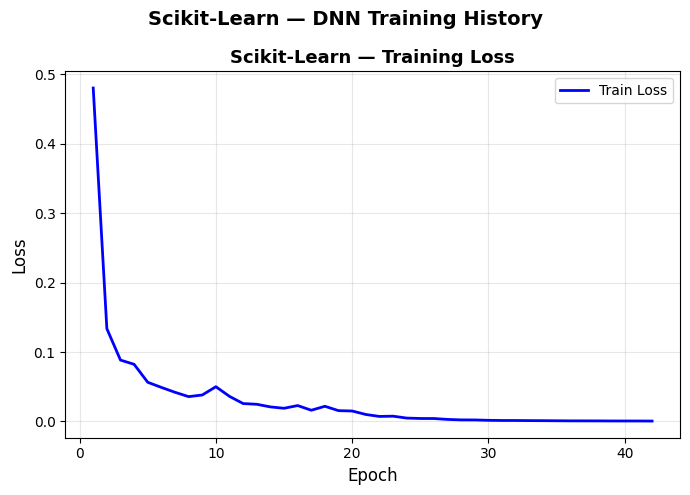

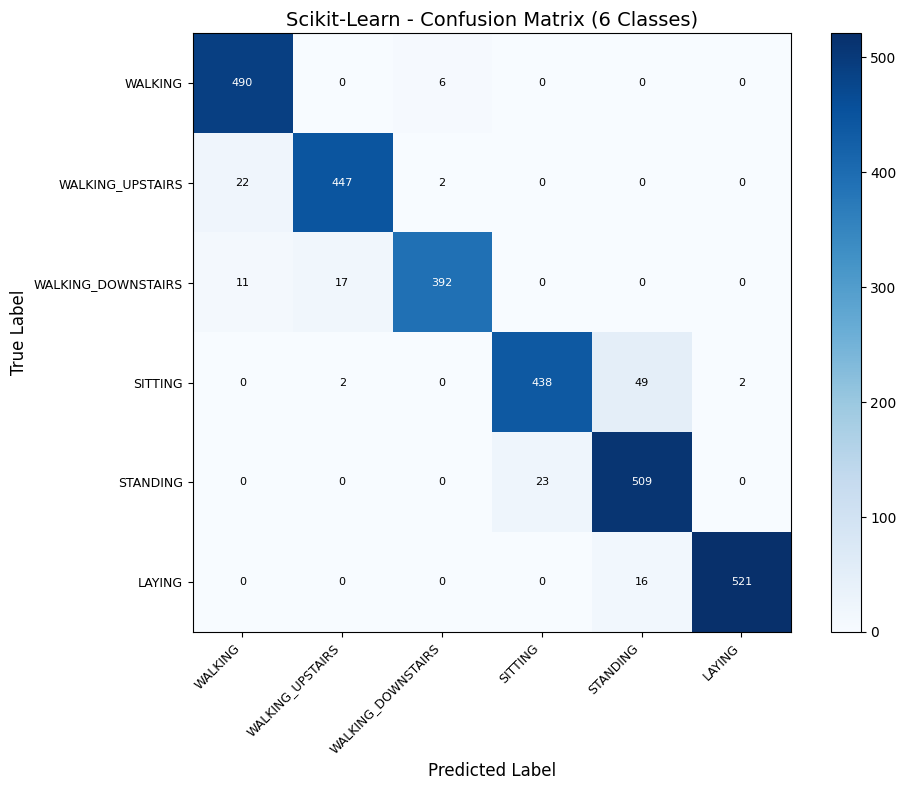

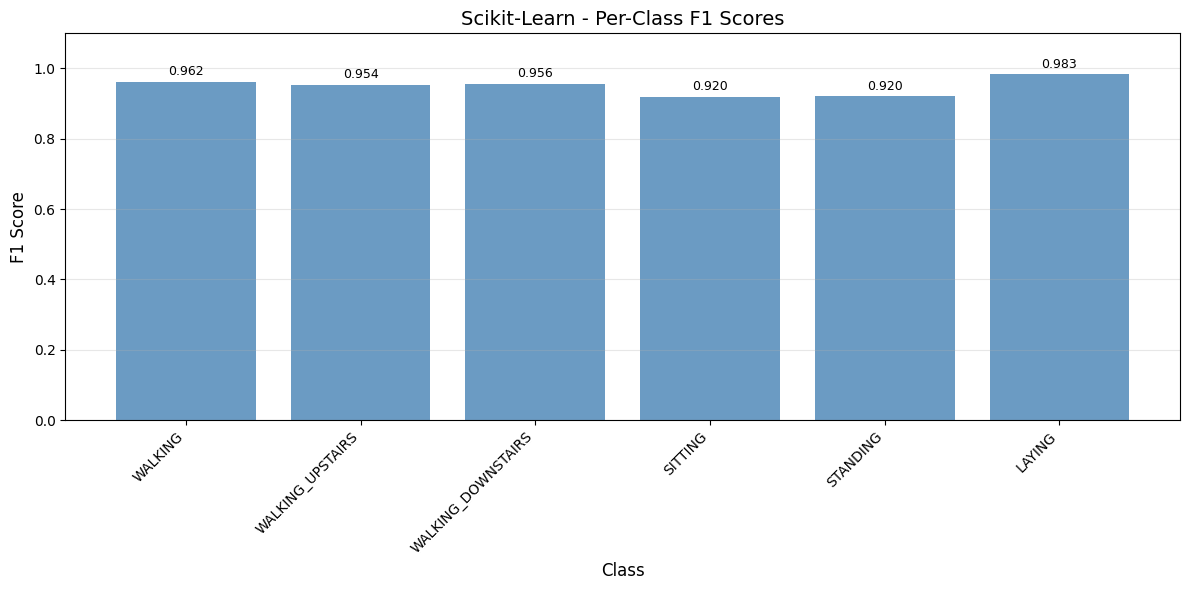

In [6]:
# Step 6: Retrain best architecture with full evaluation
# 128-64 won the sweep — now get detailed metrics + visualizations

print("=" * 60)
print("[6/8] BEST MODEL — FULL EVALUATION")
print("=" * 60)

best_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    verbose=False
)

with track_performance() as perf:
    best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
metrics = evaluate_classifier(y_test, y_pred)

print(f"\n  Architecture: 561 → 128 → 64 → 6")
print(f"  Epochs: {best_model.n_iter_}")
print(f"  Training time: {perf['time']:.2f}s")
print(f"\n  Test Metrics:")
print(f"    Accuracy:  {metrics['accuracy']:.4f}")
print(f"    Macro F1:  {metrics['macro_f1']:.4f}")

# Training history
history = {
    'train_loss': best_model.loss_curve_,
    'val_acc': best_model.validation_scores_
}
plot_training_history(history, FRAMEWORK,
                      save_path=f'{RESULTS_DIR}/training_history_best.png')

# Confusion matrix
plot_confusion_matrix_multiclass(y_test, y_pred, ACTIVITY_NAMES, FRAMEWORK,
                                  save_path=f'{RESULTS_DIR}/confusion_matrix.png')

# Per-class F1
plot_per_class_f1(y_test, y_pred, ACTIVITY_NAMES, FRAMEWORK,
                   save_path=f'{RESULTS_DIR}/per_class_f1.png')

In [7]:
# Step 7: Performance benchmarks — timing, inference, model size
print("=" * 60)
print("[7/8] PERFORMANCE BENCHMARKS")
print("=" * 60)

# Training time already captured above
print(f"\n  Training time: {perf['time']:.2f}s")
print(f"  Memory: {perf['memory']:.2f} MB")

# Inference benchmark
inference_result = track_inference(best_model.predict, X_test)
print(f"\n  Inference ({X_test.shape[0]} samples):")
print(f"    Total: {inference_result['total_time']:.4f}s")
print(f"    Per sample: {inference_result['per_sample_us']:.2f} µs")

# Model size — compute from weight arrays directly
# MLPClassifier stores weights in coefs_ (list of arrays) and intercepts_ (list of arrays)
model_bytes = sum(c.nbytes for c in best_model.coefs_) + sum(b.nbytes for b in best_model.intercepts_)
model_size = model_bytes
print(f"\n  Model size: {model_size / 1024:.2f} KB")

# Parameter count
n_params = sum(c.size + b.size for c, b in zip(best_model.coefs_, best_model.intercepts_))
print(f"  Parameters: {n_params:,}")
print(f"  Architecture: 561 → 128 → 64 → 6")
print(f"  Layers: {len(best_model.coefs_)}")

[7/8] PERFORMANCE BENCHMARKS

  Training time: 2.37s
  Memory: 19.60 MB

  Inference (2947 samples):
    Total: 0.0020s
    Per sample: 0.66 µs

  Model size: 314.77 KB
  Parameters: 80,582
  Architecture: 561 → 128 → 64 → 6
  Layers: 3


In [8]:
# Step 8: Save results + cross-framework comparison
print("=" * 60)
print("[8/8] SAVE RESULTS")
print("=" * 60)

test_metrics = {
    'accuracy': metrics['accuracy'],
    'macro_f1': metrics['macro_f1']
}

results = build_results_dict(
    framework=FRAMEWORK,
    model_name='DNN',
    test_metrics=test_metrics,
    perf=perf,
    inference_stats=inference_result,
    model_size=model_size,
    architecture='561-128-64-6',
    n_params=n_params,
    epochs=best_model.n_iter_,
    activation='relu',
    early_stopping=True
)

save_results(results, f'{RESULTS_DIR}/dnn.json')
print(f"\n  Results saved to {RESULTS_DIR}/dnn.json")

# Add to cross-framework comparison
add_result('dnn', results)
print_comparison('dnn')

[8/8] SAVE RESULTS
    Results saved to: results/dnn.json\metrics.json

  Results saved to results/dnn.json
    Added 'Scikit-Learn' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\dnn.json
    Frameworks recorded: 1/4

CROSS-FRAMEWORK COMPARISON: DNN
Metric                          Scikit-Learn
--------------------------------------------
model                                    DNN
training_time                         2.37 s
inference_time_per_sample_us         0.66 µs
model_size_bytes                    314.8 KB
peak_memory_mb                      19.60 MB
accuracy                              0.9491
macro_f1                              0.9493
architecture                    561-128-64-6
n_params                               80582
epochs                                    42
activation                              relu
early_stopping                          True

    Frameworks: 1/4 recorded
